# Compare SVM Losses with GridSearchCV

Due to its compatibility with the scikit-learn API, `GridSearchCV` can be used to compare `SVM`, `Smooth SVM`, and `Squared SVM` losses under a unified pipeline, identify the best loss, and select its optimal hyperparameter.

In [ ]:
## install rehline
%pip install rehline -q

In [2]:
## set up plotting style
import seaborn as sns
import matplotlib.pyplot as plt
custom_palette = ['#FFE4E1', '#3D325C']
sns.set_palette(custom_palette)

In [3]:
## simulate data
from sklearn.datasets import make_classification
import numpy as np

n, d = 10000, 5
X, y = make_classification(n_samples=n, n_features=d, random_state=42)
y = 2*y - 1

In [4]:
## compare SVM losses via GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from rehline import plq_Ridge_Classifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', plq_Ridge_Classifier(loss={'name': 'svm'}))
])

# Define the parameter grid to search
param_grid = {
    'clf__C': [0.1, 1.0, 10.0],
    'clf__loss': [{'name': 'svm'}, {'name': 'sSVM'}, {'name': 'squared SVM'}]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(pipe, param_grid, cv=5)
grid_search.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        plq_Ridge_Classifier(loss={'name': 'svm'}))]),
             param_grid={'clf__C': [0.1, 1.0, 10.0],
                         'clf__loss': [{'name': 'svm'}, {'name': 'sSVM'},
                                       {'name': 'squared SVM'}]})

In [5]:
# Print the best loss function and score
print(f"Overall Best Params: {grid_search.best_params_}")
print(f"Overall Best Score:  {grid_search.best_score_:.4f}")

Overall Best Params: {'clf__C': 0.1, 'clf__loss': {'name': 'svm'}}
Overall Best Score:  0.8922


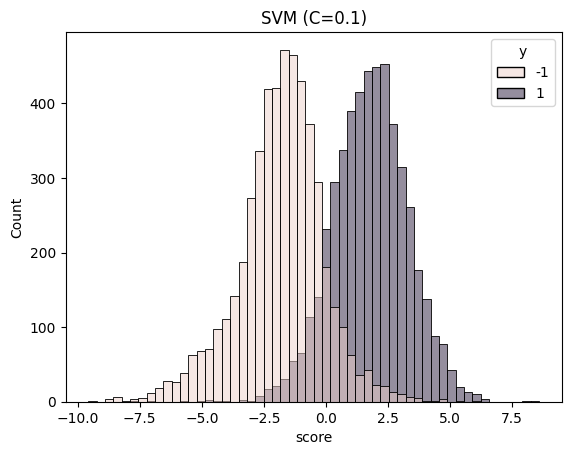

In [6]:
import seaborn as sns
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

score = grid_search.decision_function(X)
df = pd.DataFrame({'score': score, 'y': y})
sns.histplot(data=df, x="score", hue="y").set_title("SVM (C=0.1)")
plt.show()

## Compare SVM & Smooth SVM & Squared SVM

In [7]:
## print best results per loss
import pandas as pd
df = pd.DataFrame(grid_search.cv_results_)
df['Loss'] = df['param_clf__loss'].apply(lambda x: x['name'])
df = df.sort_values('mean_test_score', ascending=False)
best = df.drop_duplicates(subset=['Loss'])
table = best[['Loss', 'param_clf__C', 'mean_test_score']].rename(
    columns={'param_clf__C': 'Best C', 'mean_test_score': 'CV Score'}
)

print(table.to_string(index=False))

       Loss  Best C  CV Score
        svm     0.1    0.8922
       sSVM     0.1    0.8920
squared SVM     0.1    0.8913


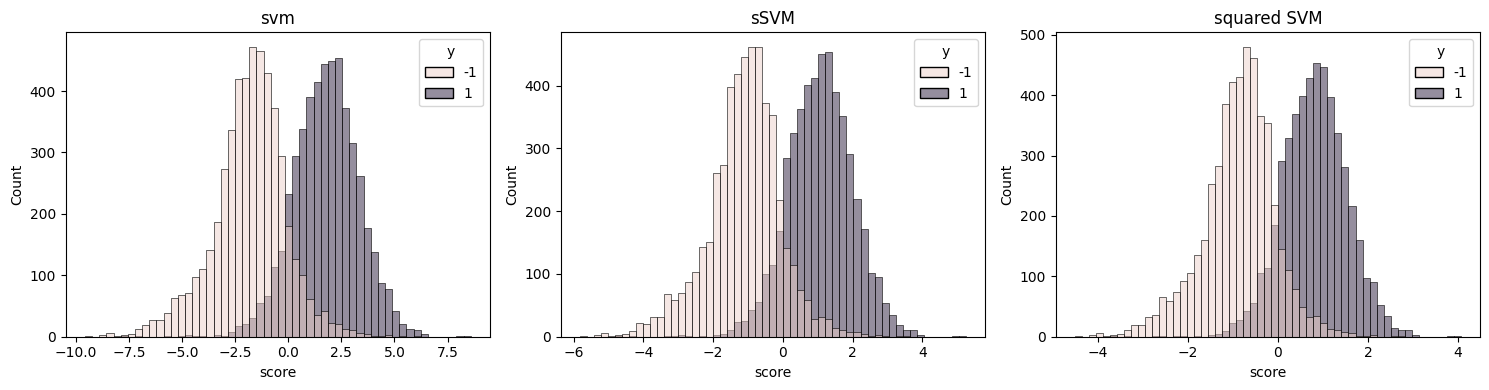

In [8]:
## plot score distributions for best models
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(len(best)):
    loss = best['Loss'].iloc[i]
    c = best['param_clf__C'].iloc[i]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', plq_Ridge_Classifier(loss={'name': loss}, C=c))
    ])
    pipe.fit(X, y)

    score = pipe.decision_function(X)
    df = pd.DataFrame({'score': score, 'y': y})
    sns.histplot(df, x="score", hue="y", ax=axes[i]).set_title(loss)

plt.tight_layout()
plt.show()